# Evasion Attacks and Defenses on Hugging Face Models using ART

In this notebook we will go over how to use ART to perform evasion attacks on a Hugging Face image classifier. We will be fine-tuning a pre-trained Data-efficient Image Transformer (DeiT) model available from Hugging Face on the CIFAR-10 dataset. We will apply the Projected Gradient Descent (PGD) attack on this model using ART functionality. Then we will be performing adversarial training to defend against such evasion attacks.

Afterwards, we will be demonstrating further functionality with Hugging Face models such as using the PyTorch Image Models (timm) library or a custom Hugging Face model using a created config.

In addition to the core ART dependencies you will need to install Pytorch and the Transformers library:

`pip install torch torchvision`

`pip install transformers`

Let's look at how we can use ART to both attack and defend Hugging Face models!


In [ ]:
#Set up new environment and installs :)

!sudo apt install python3.10-venv
!source my_env/bin/deactivate  # Deactivate current environment
!rm -rf my_env  # Remove the old environment directory
!python -m venv my_env  # Create a fresh environment
!source my_env/bin/activate  # Activate the new environment
!pip install torch torchvision transformers  # Reinstall PyTorch and related libraries
!pip install adversarial-robustness-toolbox

#!pip install --upgrade torch torchvision transformers

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  python3-pip-whl python3-setuptools-whl
The following NEW packages will be installed:
  python3-pip-whl python3-setuptools-whl python3.10-venv
0 upgraded, 3 newly installed, 0 to remove and 49 not upgraded.
Need to get 2,474 kB of archives.
After this operation, 2,885 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 python3-pip-whl all 22.0.2+dfsg-1ubuntu0.5 [1,680 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 python3-setuptools-whl all 59.6.0-1.2ubuntu0.22.04.2 [788 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 python3.10-venv amd64 3.10.12-1~22.04.6 [5,722 B]
Fetched 2,474 kB in 1s (3,212 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend ca

In [ ]:
import os
import subprocess
import sys

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import torch
import transformers

from torchvision.models import resnet50, ResNet50_Weights
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.io import read_image
#from art.estimators.classification.hugging_face import HuggingFaceClassifierPyTorch
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import ProjectedGradientDescentPyTorch
from art.defences.trainer import AdversarialTrainerMadryPGD
from art import config
from art.utils import load_dataset, get_file

from PIL import Image

%matplotlib inline
import matplotlib.pyplot as plt

np.random.seed(301)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip './drive/My Drive/TrafficSignDataset.zip'

In [ ]:
def normalizeData(dataPath, targetSize):
  for filename in os.listdir(dataPath):
    file_path = os.path.join(dataPath, filename)

    # Check if the file is an image (you can filter by extension if needed)
    if os.path.isfile(file_path) and filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        # Open the image
        image = Image.open(file_path)

        # Resize the image to the target size
        resized_image = image.resize(targetSize)

        # Save the resized image (overwrite the original file)
        resized_image.save(file_path)

        print(f"Resized {filename} to {targetSize}")

In [ ]:
#Normalize data
trainingDatasetPath = "./TrainingFolder"
testingDatasetPath = "./TestingFolder"

targetSize = (128, 128)

normalizeData(trainingDatasetPath, targetSize)
normalizeData(testingDatasetPath, targetSize)


Streaming output truncated to the last 5000 lines.
Resized 030_0054.png to (128, 128)
Resized 045_0008.png to (128, 128)
Resized 013_0013.png to (128, 128)
Resized 028_0016.png to (128, 128)
Resized 035_0051.png to (128, 128)
Resized 000_1_0023.png to (128, 128)
Resized 054_0040.png to (128, 128)
Resized 029_0011.png to (128, 128)
Resized 011_1_0031.png to (128, 128)
Resized 005_1_0058.png to (128, 128)
Resized 011_1_0066.png to (128, 128)
Resized 000_0033.png to (128, 128)
Resized 054_1_0064.png to (128, 128)
Resized 011_0044.png to (128, 128)
Resized 007_1_0042.png to (128, 128)
Resized 046_0003.png to (128, 128)
Resized 045_0006.png to (128, 128)
Resized 027_1_0007.png to (128, 128)
Resized 035_0074.png to (128, 128)
Resized 041_1_0006.png to (128, 128)
Resized 002_1_0014.png to (128, 128)
Resized 044_1_0006.png to (128, 128)
Resized 028_1_0222.png to (128, 128)
Resized 012_0018.png to (128, 128)
Resized 045_1_0003.png to (128, 128)
Resized 028_1_0080.png to (128, 128)
Resized 028_1

In [ ]:
# We will use a small subset of the CIFAR-10 dataset

(x_train, y_train), (_, _), _, _ =  #load_dataset('cifar10') #use a different dataset maybe
x_train = np.transpose(x_train, (0, 3, 1, 2)).astype(np.float32)
y_train = np.argmax(y_train, axis=1)

classes = np.unique(y_train)
samples_per_class = 100

x_subset = []
y_subset = []

for c in classes:
    indices = y_train == c
    x_subset.append(x_train[indices][:samples_per_class])
    y_subset.append(y_train[indices][:samples_per_class])

x_subset = np.concatenate(x_subset)
y_subset = np.concatenate(y_subset)

print(f'x_subset:', x_subset.dtype, x_subset.shape)
print(f'y_subset:', y_subset.dtype, y_subset.shape)

x_subset: float32 (1000, 3, 32, 32)
y_subset: int64 (1000,)


In [ ]:
label_names = [ #change these according to the dataset.
    "Speed limit (5km/h)",
    "Speed limit (15km/h)",
    "Speed limit (30km/h)",
    "Speed limit (40km/h)",
    "Speed limit (50km/h)",
    "Speed limit (60km/h)",
    "Speed limit (70km/h)",
    "Speed limit (80km/h)",
    "Dont Go straight or left",
    "Dont Go straight or Right", #Limit to 10 for the sake of testing
]

In [ ]:
# Create state_dicts directory for saving models

if not os.path.isdir('./state_dicts'):
    os.mkdir('./state_dicts')

## Regular Training with ART

We will first see how to load a model into ART's HuggingFaceClassifierPyTorch, train it, and attack it with PGD.

In [ ]:
# The HuggingFaceClassifierPyTorch follows broadly the same API as the PyTorchClassifier
# So we can supply the loss function, the input shape of the data we will supply, the optimizer, etc.
# Note, frequently we will be performing fine-tuning or transfer learning with vision transformers and
# so we may be fine-tuning on differently sized inputs.
# The input_shape argument refers to the shape of the supplied input data which may be different to
# the shape required by the model.
# To handle this HuggingFaceClassifierPyTorch has an extra argument of processor which will act on
# every batch to process the data into the correct form required by the supplied model.
# This needs to be manually specified by the user. For many attacks and defences to work it needs to be a
# differentiable function.
# Here the processor is a simple upsampler to enlarge the cifar images into the right size.

model = transformers.AutoModelForImageClassification.from_pretrained( #here is the pretrained model.
    'facebook/deit-tiny-distilled-patch16-224',
    ignore_mismatched_sizes=True,
    num_labels=10
)
upsampler = torch.nn.Upsample(scale_factor=7, mode='nearest')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = torch.nn.CrossEntropyLoss()

hf_model = HuggingFaceClassifierPyTorch(
    model=model,
    loss=loss_fn,
    optimizer=optimizer,
    input_shape=(3, 32, 32),
    nb_classes=10,
    clip_values=(0, 1),
    processor=upsampler
)

config.json:   0%|          | 0.00/69.6k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/23.7M [00:00<?, ?B/s]

Some weights of DeiTForImageClassificationWithTeacher were not initialized from the model checkpoint at facebook/deit-tiny-distilled-patch16-224 and are newly initialized because the shapes did not match:
- cls_classifier.weight: found shape torch.Size([1000, 192]) in the checkpoint and torch.Size([10, 192]) in the model instantiated
- cls_classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- distillation_classifier.weight: found shape torch.Size([1000, 192]) in the checkpoint and torch.Size([10, 192]) in the model instantiated
- distillation_classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# load saved model if it already exists, otherwise train it
#check location and change name to new model.
model_checkpoint_path = './state_dicts/deit_cifar_base_model.pt'
if os.path.isfile(model_checkpoint_path):
    hf_model.model.load_state_dict(torch.load(model_checkpoint_path, map_location=device))
    print('loaded model checkpoint')
else:
    hf_model.fit(x_subset, y_subset, nb_epochs=5)
    torch.save(hf_model.model.state_dict(), model_checkpoint_path)
    print('saved model checkpoint')

model.safetensors:   0%|          | 0.00/23.7M [00:00<?, ?B/s]

saved model checkpoint


Training takes too long. Checkpoint and save it on a file included in the Google Drive for students.

In [ ]:
outputs = hf_model.predict(x_subset)
clean_preds = np.argmax(outputs, axis=1)
clean_acc = np.mean(clean_preds == y_subset)
print('clean accuracy:', clean_acc)

clean accuracy: 0.947


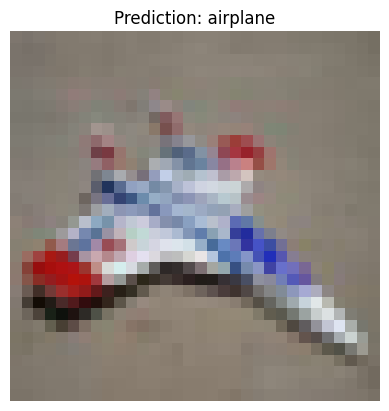

In [ ]:
plt.imshow(np.transpose(x_subset[1], (1, 2, 0)))
plt.title(f'Prediction: {label_names[clean_preds[1]]}')
plt.axis('off')
plt.show()

In [ ]:
# load adversarial samples if they already exist, otherwise generate them

adv_samples_path = './state_dicts/x_adv_base.npy'
if os.path.isfile(adv_samples_path):
    x_adv = np.load(adv_samples_path)
else:
    attacker = ProjectedGradientDescentPyTorch(hf_model, eps=8/255, eps_step=1/255)
    x_adv = attacker.generate(x_subset)
    np.save(adv_samples_path, x_adv)

outputs = hf_model.predict(x_adv)
adv_preds = np.argmax(outputs, axis=1)
adv_acc = np.mean(adv_preds == y_subset)
print('adversarial accuracy:', adv_acc)

PGD - Batches:   0%|          | 0/32 [00:00<?, ?it/s]

adversarial accuracy: 0.018


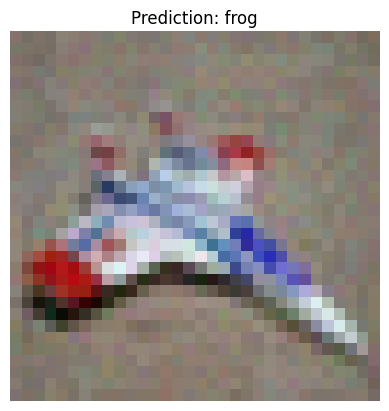

In [ ]:
plt.imshow(np.transpose(x_adv[1], (1, 2, 0)))
plt.title(f'Prediction: {label_names[adv_preds[1]]}')
plt.axis('off')
plt.show()

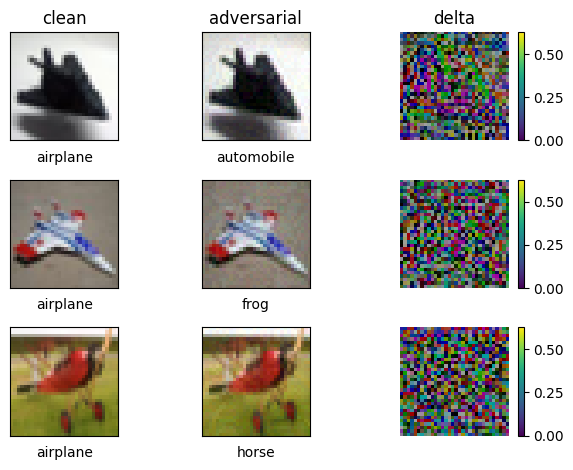

In [ ]:
# We can display the adversarial examples to highlight the added perturbation to the original sample.

# shift to have min 0 and make perturbations 10x larger to visualize them.
delta = ((x_subset - x_adv) + 8/255) * 10

fig, axs = plt.subplots(3, 3)
for i in range(3):
    axs[i, 0].imshow(np.transpose(x_subset[i], (1, 2, 0)))
    axs[i, 0].set_xlabel(label_names[clean_preds[i]])
    axs[i, 0].tick_params(axis='both', which='both',length=0)
    axs[i, 0].axes.xaxis.set_ticklabels([])
    axs[i, 0].axes.yaxis.set_ticklabels([])
    axs[i, 1].imshow(np.transpose(x_adv[i], (1, 2, 0)))
    axs[i, 1].axes.xaxis.set_ticklabels([])
    axs[i, 1].axes.yaxis.set_ticklabels([])
    axs[i, 1].tick_params(axis='both', which='both',length=0)
    axs[i, 1].set_xlabel(label_names[adv_preds[i]])
    im = axs[i, 2].imshow(np.transpose(delta[i], (1, 2, 0)))
    axs[i, 2].axis('off')
    fig.colorbar(im)

axs[0, 0].set_title('clean')
axs[0, 1].set_title('adversarial')
axs[0, 2].set_title('delta')
plt.tight_layout()

## Adversarial Training with ART

Now, rather than using regular training, we employ robust PGD training and evaluate the robust model.

In [ ]:

model = transformers.AutoModelForImageClassification.from_pretrained(
    'facebook/deit-tiny-distilled-patch16-224',
    ignore_mismatched_sizes=True,
    num_labels=10
)
upsampler = torch.nn.Upsample(scale_factor=7, mode='nearest')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = torch.nn.CrossEntropyLoss()

hf_model = HuggingFaceClassifierPyTorch(
    model=model,
    loss=loss_fn,
    optimizer=optimizer,
    input_shape=(3, 32, 32),
    nb_classes=10,
    clip_values=(0, 1),
    processor=upsampler
)

trainer = AdversarialTrainerMadryPGD(
    classifier=hf_model,
    nb_epochs=10,
    eps=8/255,
    eps_step=1/255,
    max_iter=10
)

Some weights of DeiTForImageClassificationWithTeacher were not initialized from the model checkpoint at facebook/deit-tiny-distilled-patch16-224 and are newly initialized because the shapes did not match:
- cls_classifier.weight: found shape torch.Size([1000, 192]) in the checkpoint and torch.Size([10, 192]) in the model instantiated
- cls_classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- distillation_classifier.weight: found shape torch.Size([1000, 192]) in the checkpoint and torch.Size([10, 192]) in the model instantiated
- distillation_classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# load saved model if it already exists, otherwise train it
model_checkpoint_path = './state_dicts/deit_cifar_robust_model.pt'
if os.path.isfile(model_checkpoint_path):
    trainer.classifier.model.load_state_dict(torch.load(model_checkpoint_path, map_location=device))
    print('loaded model checkpoint')
else:
    trainer.fit(x_subset, y_subset, nb_epochs=5)
    torch.save(trainer.classifier.model.state_dict(), model_checkpoint_path)
    print('saved model checkpoint')

Precompute adv samples:   0%|          | 0/1 [00:00<?, ?it/s]

Adversarial training epochs:   0%|          | 0/5 [00:00<?, ?it/s]

saved model checkpoint


In [ ]:
outputs = trainer.classifier.predict(x_subset)
clean_preds = np.argmax(outputs, axis=1)
clean_acc = np.mean(clean_preds == y_subset)
print('clean accuracy:', clean_acc)

clean accuracy: 0.104


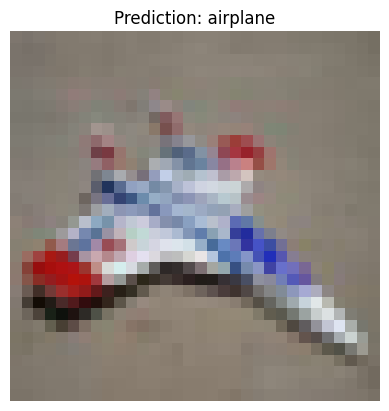

In [ ]:
plt.imshow(np.transpose(x_subset[1], (1, 2, 0)))
plt.title(f'Prediction: {label_names[clean_preds[1]]}')
plt.axis('off')
plt.show()

In [ ]:
# load adversarial samples if they already exist, otherwise generate them

adv_samples_path = './state_dicts/x_adv_robust.npy'
if os.path.isfile(adv_samples_path):
    x_adv = np.load(adv_samples_path)
else:
    attacker = ProjectedGradientDescentPyTorch(trainer.classifier, eps=8/255, eps_step=1/255)
    x_adv = attacker.generate(x_subset)
    np.save(adv_samples_path, x_adv)

outputs = trainer.classifier.predict(x_adv)
adv_preds = np.argmax(outputs, axis=1)
adv_acc = np.mean(adv_preds == y_subset)
print('adversarial accuracy:', adv_acc)

PGD - Batches:   0%|          | 0/32 [00:00<?, ?it/s]

adversarial accuracy: 0.113


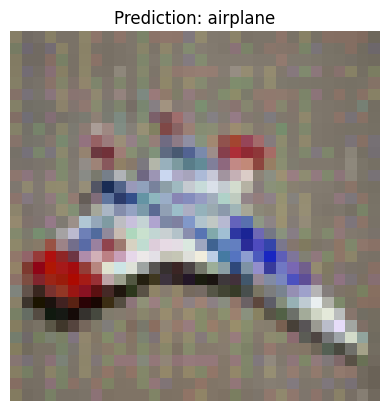

In [ ]:
plt.imshow(np.transpose(x_adv[1], (1, 2, 0)))
plt.title(f'Prediction: {label_names[adv_preds[1]]}')
plt.axis('off')
plt.show()

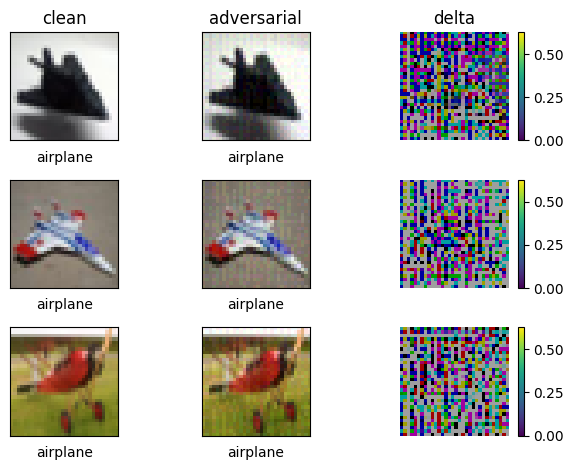

In [ ]:
# We can display the adversarial examples to highlight the added perturbation to the original sample.

# shift to have min 0 and make perturbations 10x larger to visualize them.
delta = ((x_subset - x_adv) + 8/255) * 10

fig, axs = plt.subplots(3, 3)
for i in range(3):
    axs[i, 0].imshow(np.transpose(x_subset[i], (1, 2, 0)))
    axs[i, 0].set_xlabel(label_names[clean_preds[i]])
    axs[i, 0].tick_params(axis='both', which='both',length=0)
    axs[i, 0].axes.xaxis.set_ticklabels([])
    axs[i, 0].axes.yaxis.set_ticklabels([])
    axs[i, 1].imshow(np.transpose(x_adv[i], (1, 2, 0)))
    axs[i, 1].axes.xaxis.set_ticklabels([])
    axs[i, 1].axes.yaxis.set_ticklabels([])
    axs[i, 1].tick_params(axis='both', which='both',length=0)
    axs[i, 1].set_xlabel(label_names[adv_preds[i]])
    im = axs[i, 2].imshow(np.transpose(delta[i], (1, 2, 0)))
    axs[i, 2].axis('off')
    fig.colorbar(im)

axs[0, 0].set_title('clean')
axs[0, 1].set_title('adversarial')
axs[0, 2].set_title('delta')
plt.tight_layout()